# Series01-python: ECG signal analysis

## Goal
Display the ECG signal of leads I, II and III in standard units
(millivolts vs seconds).

## Steps
1. Load the raw data from `data/ECGu.txt`
2. Check the data is loaded correctly (values, shape)
3. Rescale the amplitudes to mV using the A/D gain
4. Build the time axis from the sampling frequency
5. Plot the ECG signal
6. Check the plot against what is expected of a normal ECG

## Setup

Libraries, equipment constants, and the functions used by the analysis.

In [24]:
# Imports
# numpy to manipulate the ECG data, matplotlib to plot it
import numpy as np
import matplotlib.pyplot as plt

In [25]:
ECG_FILE_PATH = "data/ECGu.txt"
SAMPLING_FREQUENCY_HZ = 1000
ADC_UNITS_PER_MILLIVOLT = 1024
LEAD_NAMES = ["I", "II", "III"]

In [26]:
def load_ecg_in_millivolts(file_path, adc_units_per_millivolt):
    """Read a raw ECG recording and convert it to millivolts.

    Returns an array of shape (n_samples, n_leads).
    """
    raw_counts = np.loadtxt(file_path)
    return raw_counts / adc_units_per_millivolt


def build_time_axis(sample_count, sampling_frequency_hz):
    """Return the timestamp in seconds of each regularly spaced sample.

    The data file contains no time column, so the time axis is reconstructed
    from the sampling frequency.
    """
    return np.arange(sample_count) / sampling_frequency_hz


def estimate_baseline(one_lead):
    """Estimate the isoelectric line of one lead, in the units of the input.

    The median is used because the signal rests on the isoelectric line for
    most of each cardiac cycle; the mean would be pulled by the QRS peaks.
    """
    return np.median(one_lead)


def find_qrs_times(one_lead, time_seconds,
                   threshold_fraction=0.5, refractory_seconds=0.3):
    """Return the times (s) at which QRS complexes start in one lead.

    A complex is detected when the absolute deviation from baseline rises
    above threshold_fraction of its maximum. Absolute deviation is used so
    that leads with a downward main deflection are handled too.

    Detections closer together than refractory_seconds are merged: a single
    complex can cross the threshold several times in a noisy lead, and no
    real heart beats twice within 0.3 s (that would be 200 bpm).
    """
    deviation = np.abs(one_lead - estimate_baseline(one_lead))
    is_above = deviation > threshold_fraction * deviation.max()
    rising_edges = np.where(is_above[1:] & ~is_above[:-1])[0] + 1

    qrs_times = []
    for timestamp in time_seconds[rising_edges]:
        if not qrs_times or timestamp - qrs_times[-1] > refractory_seconds:
            qrs_times.append(timestamp)
    return np.array(qrs_times)


def compute_heart_rate(qrs_times, duration_seconds):
    """Heart rate in beats per minute from detected QRS times."""
    return len(qrs_times) / duration_seconds * 60


def plot_ecg_leads_overlaid(time_seconds, ecg_millivolts, lead_names):
    """Draw all leads overlaid on a single axis, to compare timing across leads."""
    figure = plt.figure(figsize=(12, 5))
    for lead_index in range(ecg_millivolts.shape[1]):
        plt.plot(time_seconds, ecg_millivolts[:, lead_index], linewidth=0.8)
    plt.xlabel("Time (s)")
    plt.ylabel("ECG (mV)")
    plt.title("ECG Signals")
    plt.legend([f"Lead {name}" for name in lead_names])
    plt.grid()
    return figure


def plot_ecg_leads(time_seconds, ecg_millivolts, lead_names):
    """Draw one panel per lead on clinical ECG paper.

    The grid follows the 25 mm/s and 10 mm/mV convention: small squares of
    0.04 s by 0.1 mV, large squares of 0.2 s by 0.5 mV. The aspect ratio is
    fixed so a large square is square on screen, as on paper, which is what
    makes intervals readable off the grid by eye.

    All panels share one vertical scale so amplitudes stay comparable
    between leads.
    """
    SECONDS_PER_SMALL_SQUARE = 0.04
    SECONDS_PER_LARGE_SQUARE = 0.2
    MILLIVOLTS_PER_SMALL_SQUARE = 0.1
    MILLIVOLTS_PER_LARGE_SQUARE = 0.5

    duration_seconds = time_seconds[-1]
    lowest_millivolts = np.floor(ecg_millivolts.min() / MILLIVOLTS_PER_LARGE_SQUARE) * MILLIVOLTS_PER_LARGE_SQUARE
    highest_millivolts = np.ceil(ecg_millivolts.max() / MILLIVOLTS_PER_LARGE_SQUARE) * MILLIVOLTS_PER_LARGE_SQUARE

    figure, axes = plt.subplots(len(lead_names), 1, sharex=True, figsize=(14, 10))

    for lead_index, axis in enumerate(axes):
        # the + step keeps the last gridline: np.arange excludes its endpoint
        axis.set_xticks(np.arange(0, duration_seconds + SECONDS_PER_LARGE_SQUARE,
                                  SECONDS_PER_LARGE_SQUARE))
        axis.set_xticks(np.arange(0, duration_seconds + SECONDS_PER_SMALL_SQUARE,
                                  SECONDS_PER_SMALL_SQUARE), minor=True)
        axis.set_yticks(np.arange(lowest_millivolts,
                                  highest_millivolts + MILLIVOLTS_PER_LARGE_SQUARE,
                                  MILLIVOLTS_PER_LARGE_SQUARE))
        axis.set_yticks(np.arange(lowest_millivolts,
                                  highest_millivolts + MILLIVOLTS_PER_SMALL_SQUARE,
                                  MILLIVOLTS_PER_SMALL_SQUARE), minor=True)
        axis.grid(True, which="major", color="red", linestyle="-", alpha=0.4)
        axis.grid(True, which="minor", color="lightcoral", linestyle="-", alpha=0.2)

        axis.plot(time_seconds, ecg_millivolts[:, lead_index],
                  color="blue", linewidth=1.2)
        axis.set_ylabel(f"Lead {lead_names[lead_index]} (mV)")
        axis.set_xlim(0, duration_seconds)
        axis.set_ylim(lowest_millivolts, highest_millivolts)
        axis.set_aspect(SECONDS_PER_LARGE_SQUARE / MILLIVOLTS_PER_LARGE_SQUARE)

    axes[0].set_title("ECG recording - three leads", pad=20)
    axes[-1].set_xlabel("Time (s)")
    figure.tight_layout()
    return figure

## Analysis

Load the raw data, convert the amplitudes to millivolts, reconstruct the time
axis, and plot the three leads.

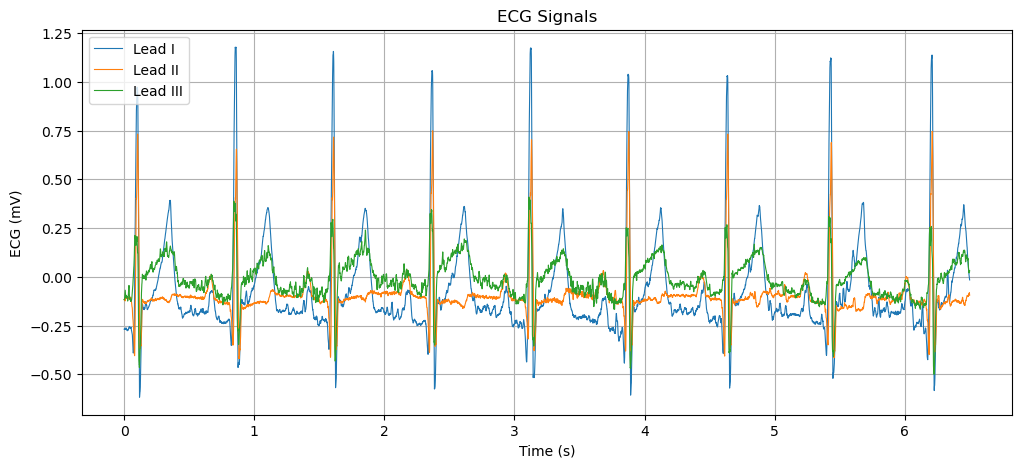

In [27]:
ecg_millivolts = load_ecg_in_millivolts(ECG_FILE_PATH, ADC_UNITS_PER_MILLIVOLT)
time_seconds = build_time_axis(len(ecg_millivolts), SAMPLING_FREQUENCY_HZ)

plot_ecg_leads_overlaid(time_seconds, ecg_millivolts, LEAD_NAMES)
plt.show()

## Checks

### Check of the rescaled ECG plot

**Are the number of timeseries correct?**
Yes. Three lines are plotted, one per column of `ecg_millivolts`, matching the
three leads (I, II, III) listed in the equipment specification.

**Are the number of samples correct?**
Yes. The array has shape (6500, 3), and at a sampling frequency of 1000 Hz this
gives 6500 / 1000 = 6.5 s of recording. The x axis of the plot runs from 0 to
6.5 s, as expected.

**Are the values consistent with the expected range of an ECG signal?**
Yes, after correcting the conversion (see below). The observed range is
-0.62 to 1.18 mV, with the R wave peaking at about 1.18 mV in lead I. A normal
limb-lead R wave is on the order of 1 mV and stays below roughly 1.5-2 mV;

**Note on the conversion formula.**
Applying the formula as written in the instructions (raw x 1024 uV) gives a
range of about -630 to +1240 mV, roughly 1000 times larger than any
physiological ECG. Dividing by 1024 instead gives values in the expected
range. The gain of 1024 is therefore best read as A/D units per millivolt
(about 0.98 uV per unit), not microvolts per unit, which is why the constant
is named `ADC_UNITS_PER_MILLIVOLT`. This should be confirmed with the
instructor.

**Additional check 1: is the heart rate plausible?**
9 QRS complexes are detected over the 6.5 s window, which gives
9 / 6.5 x 60 ~ 83 bpm. This falls in the normal sinus range of 60-100 bpm.
This check is useful because it validates the *time* axis independently of the
amplitude axis: an error in the assumed sampling frequency would produce an
implausible heart rate even if the mV values looked correct.

**Additional check 2: do the three leads agree with each other?**
Yes. All three leads return 9 complexes, at times agreeing to within about
20 ms, as they must, since the leads are simultaneous recordings of the same
heartbeats from different electrode pairs. Their amplitudes and polarities
differ, which is also expected. A time offset between leads would indicate a
loading or indexing error, for example columns read in the wrong order.


In [28]:
duration_seconds = len(ecg_millivolts) / SAMPLING_FREQUENCY_HZ
qrs_times = find_qrs_times(ecg_millivolts[:, 0], time_seconds)

print(f"leads: {ecg_millivolts.shape[1]}, samples: {ecg_millivolts.shape[0]}, "
      f"duration: {duration_seconds} s")
print(f"range: {ecg_millivolts.min():.2f} to {ecg_millivolts.max():.2f} mV")
print(f"heart rate: {compute_heart_rate(qrs_times, duration_seconds):.0f} bpm")

for lead_index, name in enumerate(LEAD_NAMES):
    times = find_qrs_times(ecg_millivolts[:, lead_index], time_seconds)
    print(f"Lead {name:4s} QRS at {np.round(times, 3)}")

leads: 3, samples: 6500, duration: 6.5 s
range: -0.62 to 1.18 mV
heart rate: 83 bpm
Lead I    QRS at [0.089 0.843 1.593 2.354 3.111 3.862 4.623 5.416 6.195]
Lead II   QRS at [0.091 0.851 1.598 2.358 3.118 3.866 4.627 5.423 6.199]
Lead III  QRS at [0.111 0.839 1.588 2.348 3.107 3.858 4.618 5.413 6.19 ]


## Realistic ECG display

The three leads are drawn on clinical ECG paper: large squares of 0.2 s by
0.5 mV, small squares of 0.04 s by 0.1 mV, with the aspect ratio fixed so that
intervals can be read off the grid by eye as on a real printout.


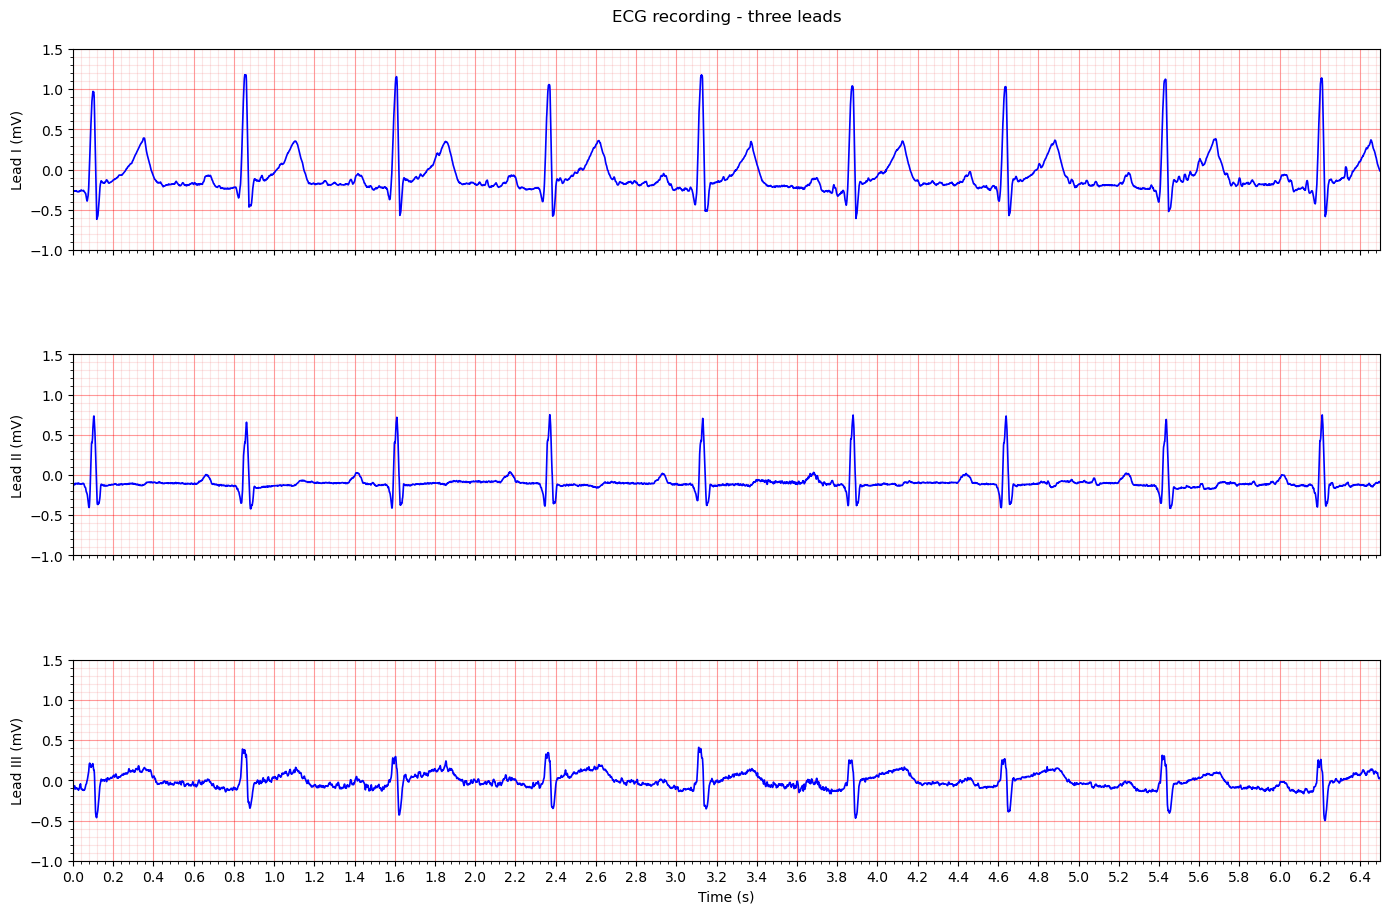

In [32]:

plot_ecg_leads(time_seconds, ecg_millivolts, LEAD_NAMES)
plt.show()